# 🚑 Ambulance vs. Non-Ambulance Image Classification

## Dataset
The dataset consists of images categorized into two classes:
- **Ambulance** (label = 1)  
- **No Ambulance** (label = 0)  

All images were resized to **64 × 64 pixels** and converted to RGB format. Each image was then normalized to values in the range **[0, 1]** and flattened into a 1D vector, resulting in feature vectors of length:

\[
64 \times 64 \times 3 = 12{,}288
\]

## Preprocessing
- Images were standardized to ensure features had zero mean and unit variance.  
- Labels were one-hot encoded for compatibility with the neural network.  
- The dataset was split into **70% training** and **30% testing** using a fixed random seed for reproducibility.

## Model: Multilayer Perceptron (MLP)
A **feedforward neural network** was built with the following architecture:

1. **Input layer**: 12,288 features (flattened image pixels)  
2. **Hidden Layer 1**: 128 neurons, activation = ReLU  
3. **Hidden Layer 2**: 64 neurons, activation = ReLU  
4. **Output Layer**: 2 neurons (Ambulance vs. No Ambulance), activation = Softmax  

### Training Details
- **Learning rate**: 0.01  
- **Loss function**: Mean Squared Error (MSE)  
- **Epochs**: 100  
- **Training mode**: Batch (not stochastic)  

## Evaluation
After training, predictions were made on the test set. A **confusion matrix** was generated to visualize classification performance, showing how well the MLP distinguished between ambulance and non-ambulance images.

---
This pipeline demonstrates how raw image data can be transformed into numerical vectors and classified effectively using a multilayer perceptron.


In [1]:
import os
import numpy as np
from PIL import Image

# --- 1. Define dataset path ---
dataset_path = "carsdataset"
categories = ["ambulance", "noambulance"]

# --- 2. Parameters ---
img_size = (64, 64)  # resize all images to 64x64

X = []
y = []

# --- 3. Load and preprocess images ---
for label, category in enumerate(categories):
    folder = os.path.join(dataset_path, category)
    for filename in os.listdir(folder):
        if filename.lower().endswith(".jpg"):
            img_path = os.path.join(folder, filename)
            try:
                # Load image
                img = Image.open(img_path).convert("RGB")
                img = img.resize(img_size)

                # Convert to numpy array
                arr = np.array(img, dtype=np.float32) / 255.0  # normalize to [0,1]

                # Flatten to 1D vector
                arr_flat = arr.flatten()

                # Append to dataset
                X.append(arr_flat)
                y.append(label)  # 1 = ambulance, 0 = noambulance
            except Exception as e:
                print(f"Skipping {img_path}: {e}")

# --- 4. Convert to numpy arrays ---
X = np.array(X)  # shape (n_samples, n_features)
y = np.array(y)  # shape (n_samples,)

# --- 5. One-hot encode labels for MLP ---
n_classes = len(categories)
y_onehot = np.eye(n_classes)[y]  # shape (n_samples, n_classes)




Predictions: [1 0 1 0 1 1 1 1 0 1 1 0 1 1 1 0 1 1 1 0]
True labels: [0 1 1 0 0 1 1 1 0 1 1 0 0 1 1 1 1 1 1 0]


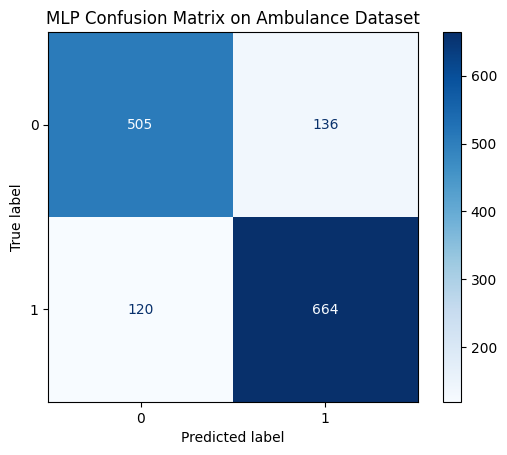

In [2]:
from ml import MultilayerPerceptron, train_test_split_arrays, standardize_vectors
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# --- 6. Standardize features ---
X = standardize_vectors(X)

# --- 7. Train-test split ---
X_train, y_train, X_test, y_test = train_test_split_arrays(
    X, y_onehot, train_ratio=0.7, seed=42
)
y_test_labels = np.argmax(y_test, axis=1)

# --- 8. Build MLP ---
mlp = MultilayerPerceptron(
    layers=[
        (X_train.shape[1], 128, "relu"),   # hidden layer 1
        (128, 64, "relu"),                 # hidden layer 2
        (64, n_classes, "softmax")         # output layer matches one-hot labels
    ],
    learning_rate=0.01,
    loss_fn="mse"
)

# --- 9. Train ---
mlp.fit(X_train, y_train, epochs=100, verbose=False, stochastic= False)

# --- 10. Predict ---
y_pred = mlp.predict(X_test)

print("Predictions:", y_pred[:20])       # show first 20 predictions
print("True labels:", y_test_labels[:20])

# --- 11. Confusion matrix ---
cm = confusion_matrix(y_test_labels, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("MLP Confusion Matrix on Ambulance Dataset")
plt.show()



In [4]:
mlp.score(X_test, y_test_labels)

0.8203508771929825

The model achieved **moderate to strong performance**, correctly classifying over **82%** of the samples. It performed **significantly better than random guessing**, with relatively low false positive and false negative rates.